# 1.import 

In [29]:
# 데이터 처리
import numpy as np
import pandas as pd
# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
# 머신러닝 관련 라이브러리
from sklearn.datasets import load_breast_cancer              # 예제 데이터
from sklearn.model_selection import train_test_split         # 데이터 분할
from sklearn.preprocessing import StandardScaler             # 정규화 
from sklearn.linear_model import LogisticRegression          # 모델 
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

# 데이터 로드

In [30]:
# 유방암 데이터셋 로드(이진 분류 문제)
data = load_breast_cancer()

# 입력 변수(feature)
X = data.data

## 정답 (target)
y = data.target

In [31]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

# 데이터 분할 (Train/Test)

In [32]:
# 데이터를 학습용/테스트용으로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,       # 20% 테스트로 사용
    random_state = 42      # 결과 재현 기능
)

# 데이터 전처리 (정규화)

In [33]:
# StandardScaler 라이브러리로 정규화 생성 (평균 = 0, 표준편차=1)
scaler = StandardScaler()

# 학습 데이터로 scaler 학습 후 변환
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 모델 생성 및 학습

In [34]:
# Logistic Regression 모델 생성
model = LogisticRegression()  

# 모델 학습
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# 예측 수행

In [39]:
# 클래스 예측 (0 또는 1)
y_pred = model.predict(X_test)

# 확률 예측
y_prod = model.predict_proba(X_test)[:, 1]

# 모델 성능 평가

In [40]:
# Accuracy 계산
acc = accuracy_score(y_test, y_pred)

# Precision 계산
precision = precision_score(y_test, y_pred)

# Recall 계산
recall = recall_score(y_test, y_pred)

# F1-Score 계산
f1 = f1_score(y_test, y_pred)

# 결과 출력
print("========= 모델 성능 =========")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Core: {f1:.4f}")

========= 모델 성능 =========
Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1-Core: 0.9790


# Confusion Matrix 시각화

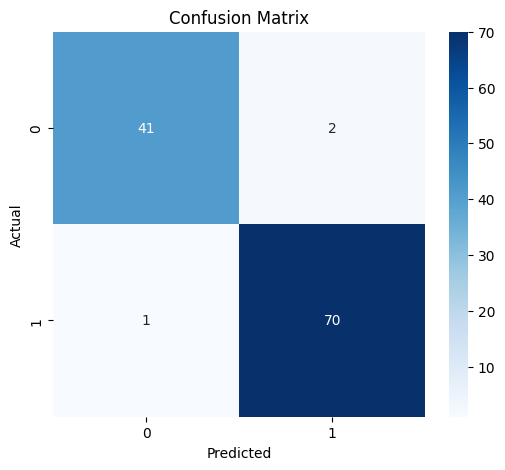

In [41]:
# Confusion Matrix 계산
cm = confusion_matrix(y_test, y_pred)

# Heatmap으로 시각화
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# 제목 및 라벨
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC Curve 시각화

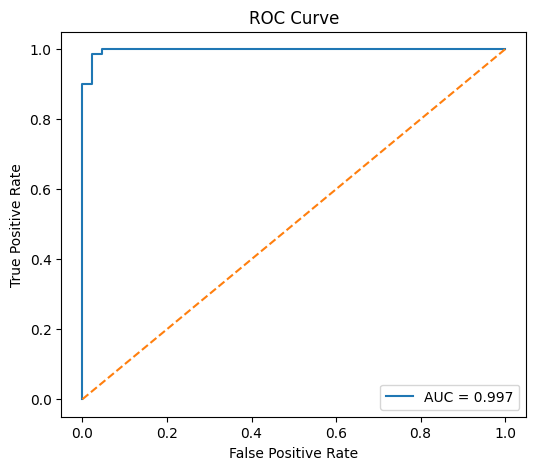

In [43]:
# FPR, TPR 계산
fpr, tpr, thresholds = roc_curve(y_test, y_prod)

# AUC 계산
roc_auc = auc(fpr, tpr)

# 그래프 그리기
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

# 기준선 (random classifier)
plt.plot([0,1], [0,1], linestyle='--')

# 라벨 설정
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

# 범례
plt.legend()

# 출력
plt.show()




# 예측 결과 시각화

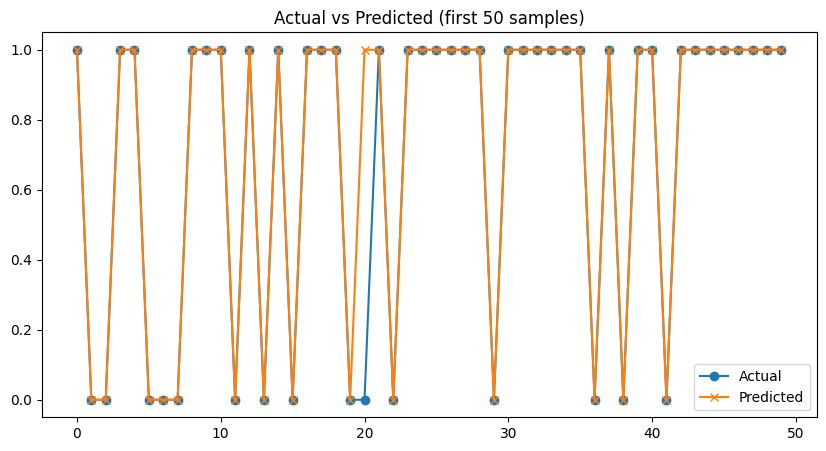

In [45]:
#실제값 vs 예측값 비교
plt.figure(figsize=(10,5))

# 실제값
plt.plot(y_test[:50], label="Actual", marker="o")

# 예측값
plt.plot(y_pred[:50], label="Predicted", marker='x')

# 제목 및 범례
plt.title("Actual vs Predicted (first 50 samples)")
plt.legend()

plt.show()